In [39]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce
import sklearn as skl
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from ressources.data.description import DESCRIPTIONS
from utils.fonctions import compute_entropies

In [40]:
def load_db():
    return pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-cleaned.parquet')

df = load_db()

Text(0.5, 1.0, 'imbalanced target')

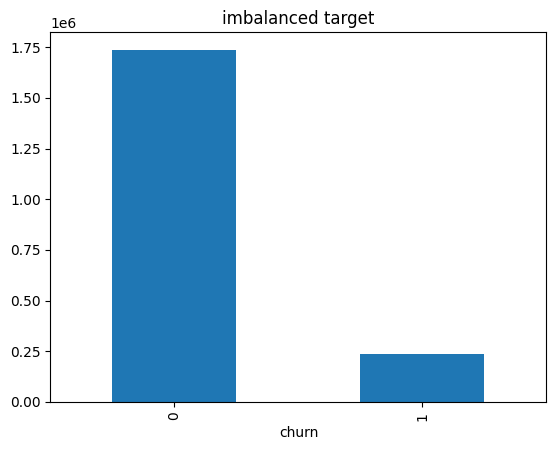

In [6]:
df.churn.value_counts().plot(kind='bar').set_title('imbalanced target')

### Equilibrer la target

*On a plusieurs méthodes pour équilibrer la target : soit un oversampling ou un undersampling*

In [5]:
from imblearn.over_sampling import SMOTE

# équilibrer la cible 'churn' avec SMOTE
smote = SMOTE(random_state=42)
X = df.drop(columns=['churn'])
y = df['churn']
X_res, y_res = smote.fit_resample(X, y)

# mettre à jour le dataframe avec les données équilibrées
churn_data_balanced = pd.concat([X_res, y_res], axis=1)
print("Données équilibrées avec SMOTE")

Données équilibrées avec SMOTE


Text(0.5, 1.0, 'balanced target with smote method')

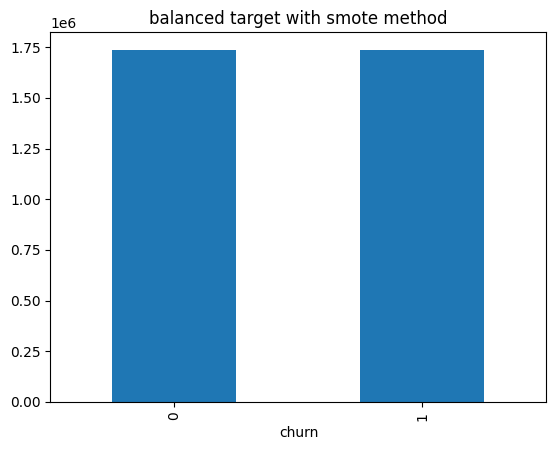

In [6]:
churn_data_balanced.churn.value_counts().plot(kind='bar').set_title('balanced target with smote method')

In [7]:
churn_data_balanced.to_parquet('../ressources/data/0_archive/Insurance_Churn_ParticipantsData/train/data-balanced-smote.parquet', compression='gzip')

Données équilibrées avec RandomUnderSampler


Text(0.5, 1.0, 'balanced target with RandomUnderSampler method')

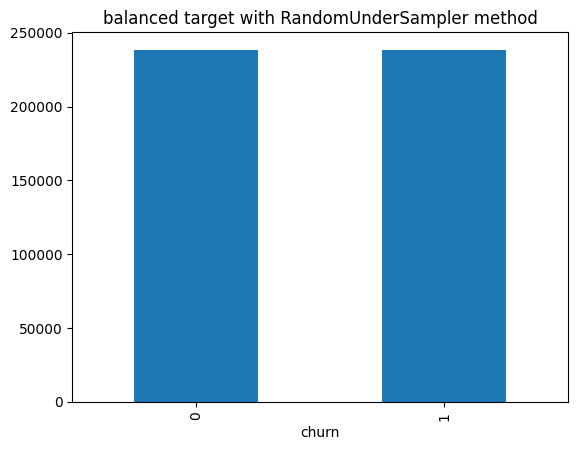

In [41]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize the RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X = df.drop(columns=['churn'])
y = df['churn']

# Apply the under-sampling
X_res, y_res = rus.fit_resample(X, y)

# Update the dataframe with the balanced data
churn_data_balanced = pd.concat([X_res, y_res], axis=1)
print("Données équilibrées avec RandomUnderSampler")

# Plot the balanced target
churn_data_balanced.churn.value_counts().plot(kind='bar').set_title('balanced target with RandomUnderSampler method')

In [9]:
churn_data_balanced.to_parquet('../ressources/data/0_archive/Insurance_Churn_ParticipantsData/train/data-balanced-rus.parquet', compression='gzip')

## Model
- FPR : erreur de prediction, on prédit 1 alors que ce n'est pas 1 - on va dire qu'ils résilient pas alors qu'ils ne résilient pas. (pas très grave)
- FNR : erreur de prediction, on prédit 0 alors que ce n'est pas 0 - on va dire qu'ils ne partiront pas alors qu'il partent. (sensibilité/recall)
- *Minimiser le fnr (faux negatifs) car ce sont des gens qu'on prédit qu'ils vont rester mais en vrai il partent.*
- Si on minimise les FNR, le recall (TP/(TP + FN)) va être maximisé ; donc on va chercher à maximiser le recall en gardant une bonne précision.
- *L'entrainement des modèles se fait via le script dans `src/pipelines/train.py` (cf. readme file)*
- *Dans cette partie on va faire des analyses supplémentaires sur les modèles (learning curves, courbes ROC, etc..)*

In [3]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV

import sys
sys.path.append('..')

from src.artifacts.model import ModelPipelineWithMlflow
from utils.fonctions import load_pickle

def load_db_rus():
    return pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-balanced-rus.parquet')

def load_db_smote():
    return pd.read_parquet(r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\train\data-balanced-smote.parquet')

TARGET = 'churn'

churn_data = load_db_rus()
print("Dataset loaded ok !")

c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset loaded ok !


In [2]:
import mlflow
from mlflow.tracking import MlflowClient

def reload_model_by_run_name(search_run_name=None, search_run_id=None, exp_name="modeles_churn", tracking_uri="http://127.0.0.1:5000"):
    """Contrainte : le serveur doit etre up"""

    mlflow.set_tracking_uri(tracking_uri)
    client = MlflowClient()

    experiment = client.get_experiment_by_name(exp_name)
    experiment_id = experiment.experiment_id

    if not search_run_id:
        runs = client.search_runs(experiment_id, filter_string=f"tags.mlflow.runName = '{search_run_name}'")
        run = runs[0]
        run_id = run.info.run_id
    else:
        run_id = search_run_id
        
    model_uri = f"../mlruns/{experiment_id}/{run_id}/artifacts/model_fitted/"
    try:
        lm = mlflow.sklearn.load_model(model_uri)
        print(f"Model {search_run_name} reloaded from MLflow experiment")
        return lm
    except Exception as e:
        print(f"Exception while loading model : {e}")

In [11]:
# ----------- reload --------
run_names = [
    "rus-scaling-and-LogisticRegression",
    "rus-scaling-and-KNeighbors",
    "rus-scaling-and-RandomForest",
    "rus-scaling-and-GradientBoosting",
    "rus-scaling-and-AdaBoost",
    "rus-scaling-and-LightGBM_v2-wo_coord",
    "rus-scaling-and-AdaBoost_v2-wo_coord",
    "rus-scaling-and-GradientBoosting_v2-wo_coord",
    "rus-scaling-and-RandomForest_v2-wo_coord",
    "rus-scaling-and-LogisticRegression_v2-wo_coord"
]

loaded_models_list = []
for rn in run_names:
    loaded_models_list.append(reload_model_by_run_name(search_run_name=rn, exp_name='modeles_churn', tracking_uri='http://127.0.0.1:5000'))


# --- lire le modele smote
run_id = "ee0563c35af842b48236f472582abed6"
smote_bmodel = reload_model_by_run_name(search_run_id=run_id)
loaded_models_list.append(smote_bmodel)

Model rus-scaling-and-LogisticRegression reloaded from MLflow experiment
Model rus-scaling-and-KNeighbors reloaded from MLflow experiment
Model rus-scaling-and-RandomForest reloaded from MLflow experiment
Model rus-scaling-and-GradientBoosting reloaded from MLflow experiment
Model rus-scaling-and-AdaBoost reloaded from MLflow experiment
Model rus-scaling-and-LightGBM_v2-wo_coord reloaded from MLflow experiment
Model rus-scaling-and-AdaBoost_v2-wo_coord reloaded from MLflow experiment
Model rus-scaling-and-GradientBoosting_v2-wo_coord reloaded from MLflow experiment
Model rus-scaling-and-RandomForest_v2-wo_coord reloaded from MLflow experiment
Model rus-scaling-and-LogisticRegression_v2-wo_coord reloaded from MLflow experiment
Model None reloaded from MLflow experiment


In [12]:
from sklearn.model_selection import train_test_split

def data_split(df, target_name, verbose=True, test_size=0.2):
    X = df[[c for c in df.columns if c != target_name]]
    y = df[target_name]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0)
    # précaution
    if target_name in X_train.columns:
        X_train.drop(target_name, axis=1)
    if target_name in X_test.columns:
        X_test.drop(target_name, axis=1)
    # baisser la taille (doxncast)
    for _ in X_train.columns:
        if X_train[_].dtype == 'float64':
            X_train[_] = X_train[_].astype('float32')
        if X_train[_].dtype == 'int64':
            X_train[_] = X_train[_].astype('int32')
            
    for _ in X_test.columns:
        if X_test[_].dtype == 'float64':
            X_test[_] = X_test[_].astype('float32')
        if X_test[_].dtype == 'int64':
            X_test[_] = X_test[_].astype('int32')

    if verbose:
        print(
            f"Train X : {X_train.shape}",
            f"Test X : {X_test.shape}",
            f"Train y : {y_train.shape}",
            f"Test y : {y_test.shape}",
            sep='\n'
        )
    return X_train, X_test, y_train, y_test

X_train_rus, X_test_rus, y_train_rus, y_test_rus = data_split(load_db_rus(), 'churn')
X_train_smote, X_test_smote, y_train_smote, y_test_smote = data_split(load_db_smote(), 'churn')

Train X : (381568, 15)
Test X : (95392, 15)
Train y : (381568,)
Test y : (95392,)
Train X : (2779380, 15)
Test X : (694846, 15)
Train y : (2779380,)
Test y : (694846,)


### LROC Curve

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(pipeline, X_test, y_test):
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{pipeline['model'].estimator.__class__.__name__} (AUC = {roc_auc:.2f})")

In [15]:
_ = [1, 2, 3]
_[-1]

3

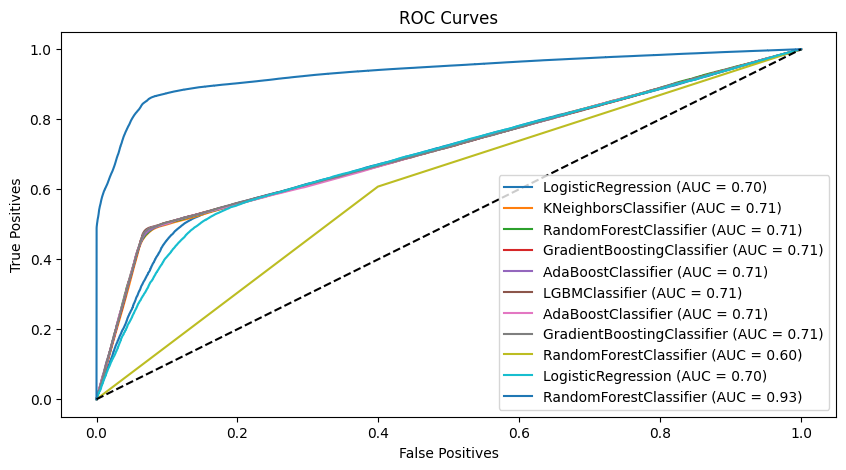

In [17]:
plt.figure(figsize=(10, 5))
for _loaded_model in loaded_models_list[:-1]:
    try:
        # plot les modeles rus à part
        plot_roc_curve(_loaded_model, X_test=X_test_rus, y_test=y_test_rus)
    except:
        raise
# et le modele smote à part 
plot_roc_curve(loaded_models_list[-1], X_test_smote, y_test_smote)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positives')
plt.ylabel('True Positives')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

*On voit que les modèles ont globalement du mal à prédire les vrai positifs. Pour rappel la target est churn (1 si la personne a résilié et 0 si non). Donc, les modèles qui prédisent le mieux la proba de résiilation sont tous les modèles **sauf la regression logistique** et le **random forest classifier** (qui est en fait un decision tree).*

In [18]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5), scorer="precision", ax=None):
    if ax is None:
        ax = plt.gca()
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Score")
    
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, scoring=scorer, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    ax.grid()
    
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    ax.legend(loc="best")
    return ax


def plot_precision_recall_curve(pipeline, X_test, y_test):
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    average_precision = average_precision_score(y_test, y_pred_proba)
    plt.plot(recall, precision, label=f"{pipeline['model'].estimator.__class__.__name__} (AvgPrecision = {average_precision:.2f})")


In [ ]:
# ------------ application 
for i, model in enumerate(loaded_models_list):
    fig, axs = plt.subplots(1, 3, figsize=(30, 5))
    plot_learning_curve(model, f"Learning Curve for Model - {model['model'].estimator.__class__.__name__} - recall", X_train, y_train, cv=2, n_jobs=-1, scorer='recall', ax=axs[0])
    plot_learning_curve(model, f"Learning Curve for Model - {model['model'].estimator.__class__.__name__} - precision", X_train, y_train, cv=2, n_jobs=-1, scorer='precision', ax=axs[1])
    plot_learning_curve(model, f"Learning Curve for Model - {model['model'].estimator.__class__.__name__} - accuracy", X_train, y_train, cv=2, n_jobs=-1, scorer='accuracy', ax=axs[2])
    plt.savefig(f"../ressources/img/rus-{model['model'].estimator.__class__.__name__}-5.png")

*Les courbes apprentissage-validation sont sauvegardées dans le répertoire `ressources/models_fitted`*

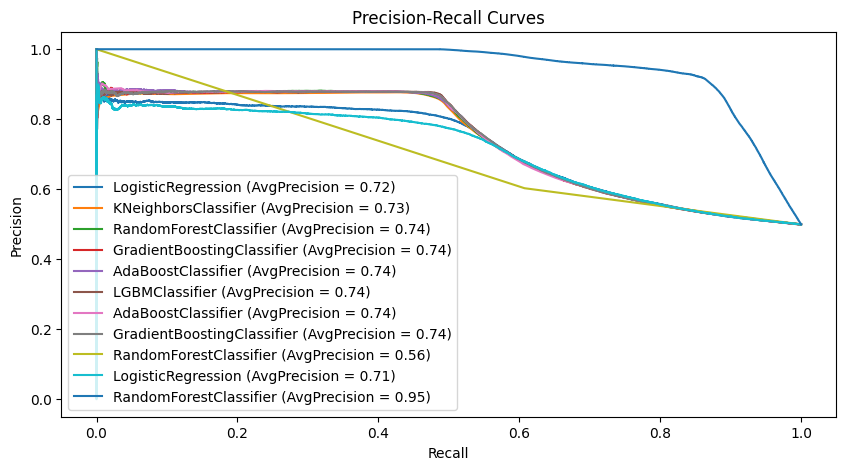

In [19]:
plt.figure(figsize=(10, 5))
for _loaded_model in loaded_models_list[:-1]:
    try:
        plot_precision_recall_curve(_loaded_model, X_test=X_test_rus, y_test=y_test_rus)
    except:
        pass
plot_precision_recall_curve(loaded_models_list[-1], X_test_smote, y_test_smote)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
plt.show()

*Ici aussi, l'évaluation montre que les modèles font quasiment le même compromis entre recall et precision. Lorsque le recall est faible, la précision est élevée mais elle baisse au fur et à mesure que le recall augmente.*

**CHOIX DU MEILLEUR MODELE**
Les deux graphiques qui comparent les recall/precision des modèles d'une part et le compromis entre Vrais positifs et Faux positifs (LROC) montrent que le meilleur modèle est le Random Forest entrainé avec les données du SMOTE. 

### Analyse du modele RFCV smote

In [ ]:
# ------------ learning curves 
for i, model in enumerate([smote_bmodel]):
    fig, axs = plt.subplots(1, 3, figsize=(30, 5))
    plot_learning_curve(model, f"Learning Curve for Model - {model['model'].estimator.__class__.__name__} - recall", X_train, y_train, cv=2, n_jobs=-1, scorer='recall', ax=axs[0])
    plot_learning_curve(model, f"Learning Curve for Model - {model['model'].estimator.__class__.__name__} - precision", X_train, y_train, cv=2, n_jobs=-1, scorer='precision', ax=axs[1])
    plot_learning_curve(model, f"Learning Curve for Model - {model['model'].estimator.__class__.__name__} - accuracy", X_train, y_train, cv=2, n_jobs=-1, scorer='accuracy', ax=axs[2])
    plt.savefig(f"../ressources/img/rus-{model['model'].estimator.__class__.__name__}-10.png")


## OOM error !

*Note : Je n'arrive pas exécuter ceci dans le notebook (Out of memory error) après plusieurs reprises... donc je ne peux visualiser les learning curves du modele smote.*

In [41]:
# features importance lors de l'apprentissage (car c'est un modèle random forest)
rf_model = smote_bmodel['model'].best_estimator_
feature_importances = rf_model.feature_importances_

feature_names = smote_bmodel['scaling'].get_feature_names_out()
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df['Feature'] = importance_df['Feature'].apply(lambda n: n.replace('remainder__', '').replace('_0', '').replace('standard_scaler__', ''))
importance_df['description'] = [DESCRIPTIONS.get(_, '') for _ in importance_df.Feature.values]
importance_df

,Feature,Importance,description
7,DAYS_TENURE,0.318481,The time in days individual has been a custome...
8,HAS_CHILDREN,0.194264,"Flag, 1 indicates the individual has children ..."
11,COLLEGE_DEGREE,0.170482,"Flag, 1 individual has a college degree or mor..."
10,HOME_OWNER,0.111954,"Flag, 1 individual owns primary home, 0 otherw..."
12,GOOD_CREDIT,0.072750,"Flag, 1 individual has FICO greater than 630, ..."
9,LENGTH_OF_RESIDENCE,0.048634,Estimated number of years the individual has l...
6,HOME_MARKET_VALUE,0.029239,Estimate value of home.
4,MARITAL_STATUS,0.019881,Estimated marital status. Married or Single.
3,COUNTY,0.009959,
13,LATITUDE,0.006422,Lattitude of the address


In [45]:
import pickle
with open('../ressources/models_fitted/smote-augmentation-sacling-rfcv/importances_df.pkl', 'wb') as f:
    pickle.dump(importance_df, f)

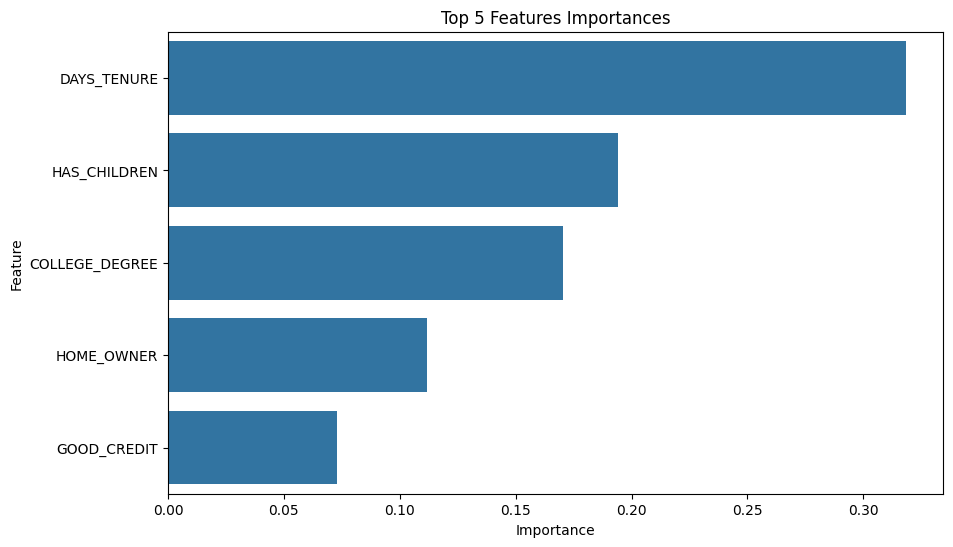

<Figure size 640x480 with 0 Axes>

In [44]:
# plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(5), x='Importance', y='Feature')
plt.title('Top 5 Features Importances')
plt.show()

plt.savefig('../ressources/models_fitted/smote-augmentation-sacling-rfcv/features_importance.png')

In [ ]:
import shap

# SHAP TreeExplainer sur le rf entrainé 
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
# viz
shap.summary_plot(shap_values[1], X_test, feature_names=feature_names)

### Prédiction sur la data réelle du hackathon

In [26]:
real_db_path = r'..\ressources\data\0_archive\Insurance_Churn_ParticipantsData\real\Train.csv'
real_db = pd.read_csv(real_db_path)
real_db = real_db.drop('labels', axis=1)
real_db.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15
0,-0.276515,-0.424429,1.344997,-0.012283,0.076230,1.076648,0.182198,3,0,1,0,0,0,0,10,2
1,0.853573,0.150991,0.503892,-0.979179,-0.569351,-0.411453,-0.251940,4,1,2,0,1,0,0,0,3
2,0.947747,-0.173832,1.825628,-0.703478,0.076230,-0.411453,-0.251940,6,1,2,0,0,0,0,5,3
3,0.853573,-0.381404,0.984523,-0.039464,-0.569351,-0.411453,-0.251940,4,0,2,0,1,0,0,5,3
4,1.324443,1.590527,-1.178318,-0.097711,-0.246560,-0.411453,-0.251940,0,1,1,0,0,0,0,8,3


In [58]:
X_train_scaled = loaded_models_list[0]['scaling'].fit_transform(X_train)
X_train_scaled.head()

,standard_scaler__INCOME,standard_scaler__CURR_ANN_AMT,standard_scaler__AGE_IN_YEARS,remainder__COUNTY_0,remainder__MARITAL_STATUS_0,remainder__CITY_0,remainder__HOME_MARKET_VALUE,remainder__DAYS_TENURE,remainder__HAS_CHILDREN,remainder__LENGTH_OF_RESIDENCE,remainder__HOME_OWNER,remainder__COLLEGE_DEGREE,remainder__GOOD_CREDIT,remainder__LATITUDE,remainder__LONGITUDE
1431498,-0.674441,-0.316312,1.722272,2,1,38,5.0,2946.0,1.0,15.000,1.0,0.0,1.0,32.848848,-96.948392
960553,-0.011248,-0.519460,2.159879,3,2,5,2.0,6291.0,0.0,15.000,0.0,0.0,0.0,32.763339,-97.014698
1037752,0.132555,-0.353207,-0.977120,4,1,10,6.0,5252.0,1.0,10.000,1.0,1.0,1.0,33.335757,-96.783345
1395428,-1.077939,-2.921615,0.249194,3,2,31,8.0,80.0,0.0,1.000,1.0,0.0,1.0,32.848848,-96.948392
191600,-0.573567,1.182240,0.249194,3,3,4,19.0,6022.0,0.0,6.801,0.0,0.0,0.0,32.848848,-96.948392


In [59]:
X_train_scaled['YEARS_TENURE'] = X_train_scaled['remainder__DAYS_TENURE']//365
X_train_scaled['YEARS_TENURE'].value_counts()

YEARS_TENURE
0.0     112986
17.0     75303
3.0      19384
4.0      16222
5.0      15076
2.0      13421
6.0      13112
7.0      12954
8.0      12483
9.0      11394
11.0     10914
1.0      10618
12.0     10339
13.0     10248
14.0     10162
15.0      9637
16.0      9371
10.0      7944
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

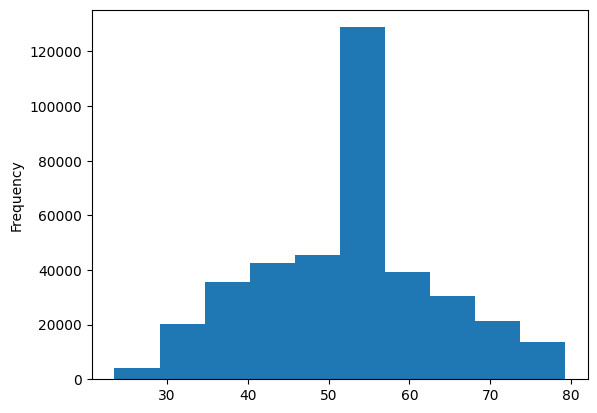

In [64]:
X_train['AGE_IN_YEARS'].plot(kind='hist')

<Axes: xlabel='YEARS_TENURE'>

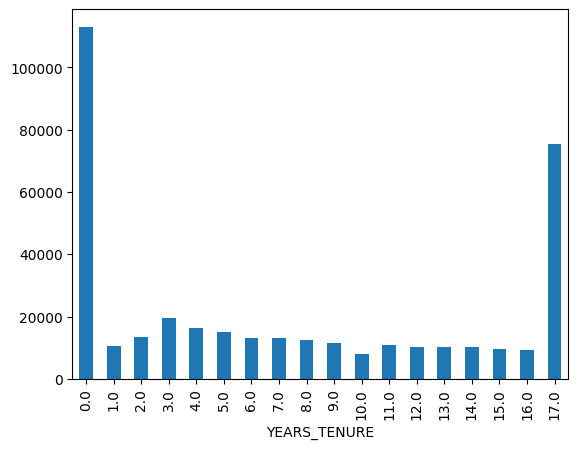

In [60]:
X_train_scaled['YEARS_TENURE'].value_counts().sort_index().plot(kind='bar')

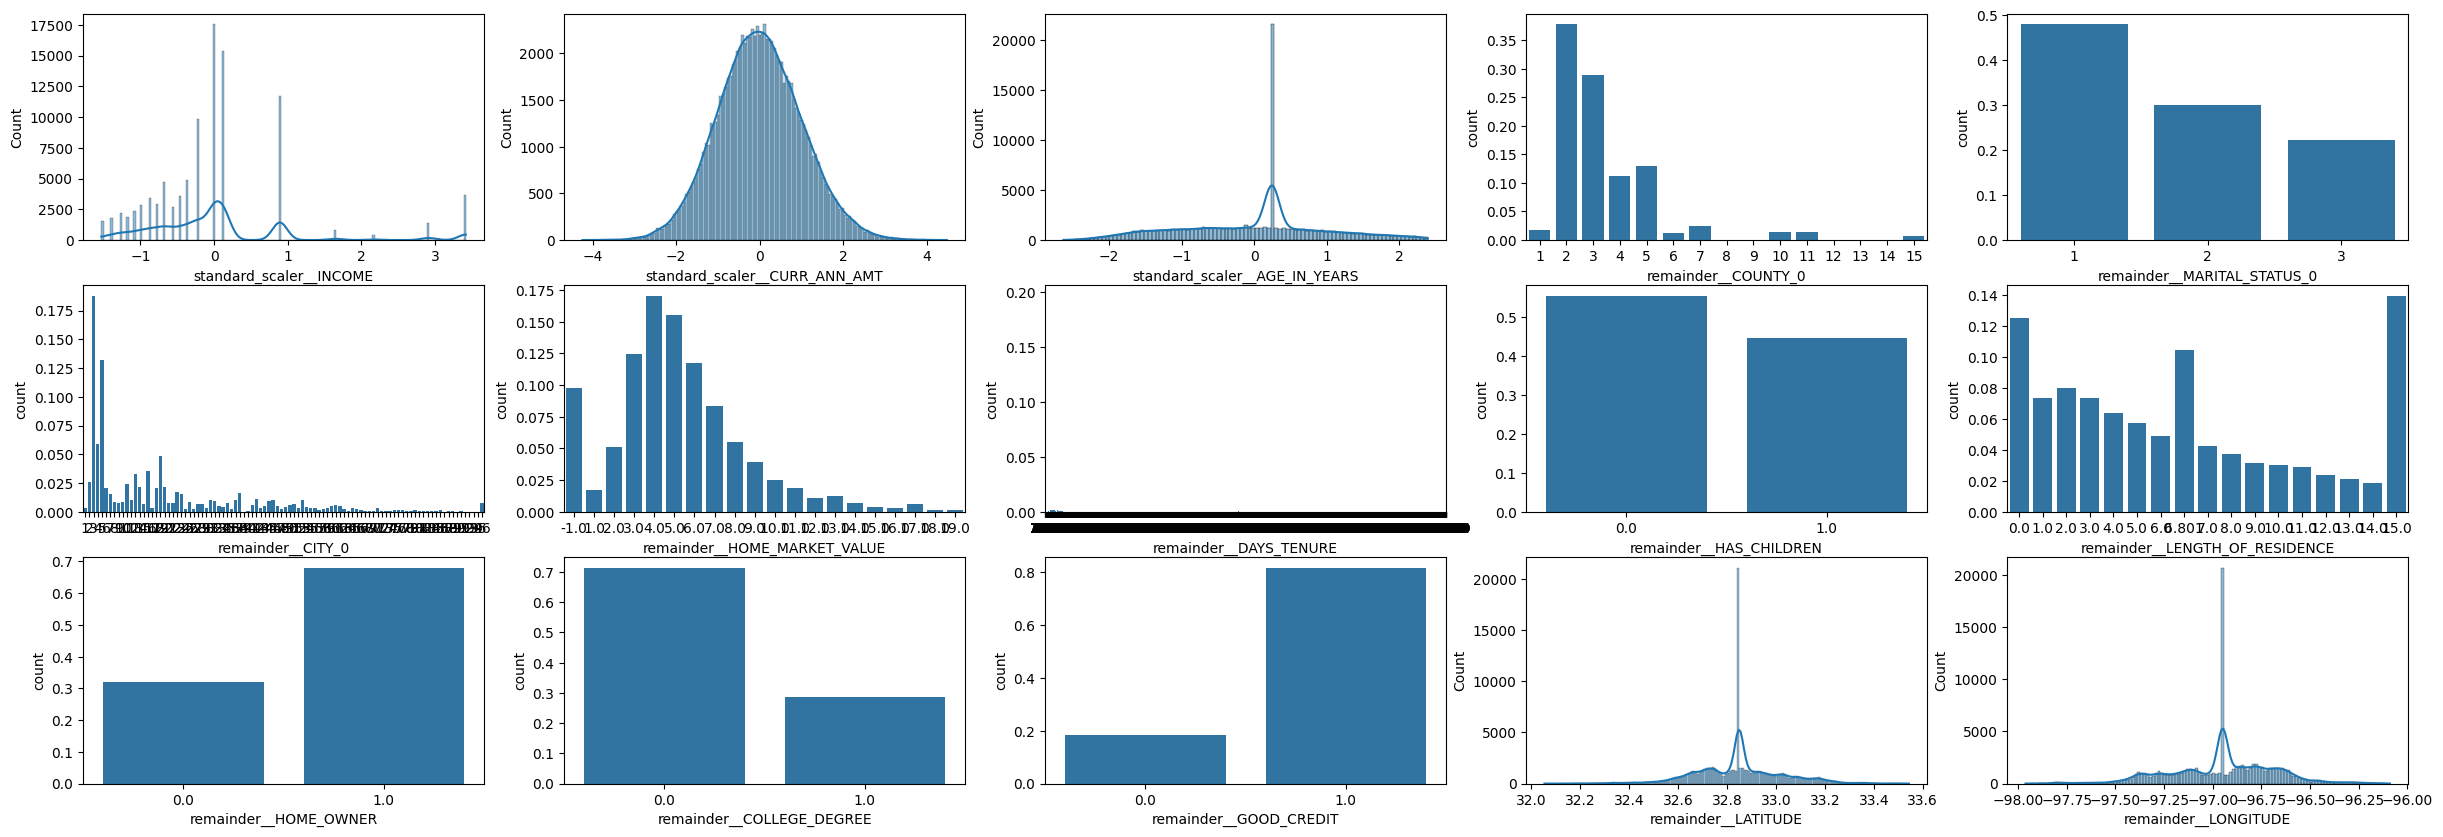

In [ ]:
import seaborn as sns
from itertools import product

fig, axs = plt.subplots(3, 5, figsize=(30, 10))
idx = list(product(range(3), range(5)))
_num_cols = [
    'standard_scaler__INCOME', 'standard_scaler__CURR_ANN_AMT',
    'standard_scaler__AGE_IN_YEARS', 
    'remainder__LATITUDE', 'remainder__LONGITUDE'
]

for i, c in zip(idx, X_train_scaled.columns):
    if c in _num_cols:
        sns.histplot(X_train_scaled[c], kde=True, ax=axs[i[0], i[1]])
    else:
        sns.barplot(X_train_scaled[c].value_counts()/X_train_scaled.shape[0], ax=axs[i[0], i[1]])

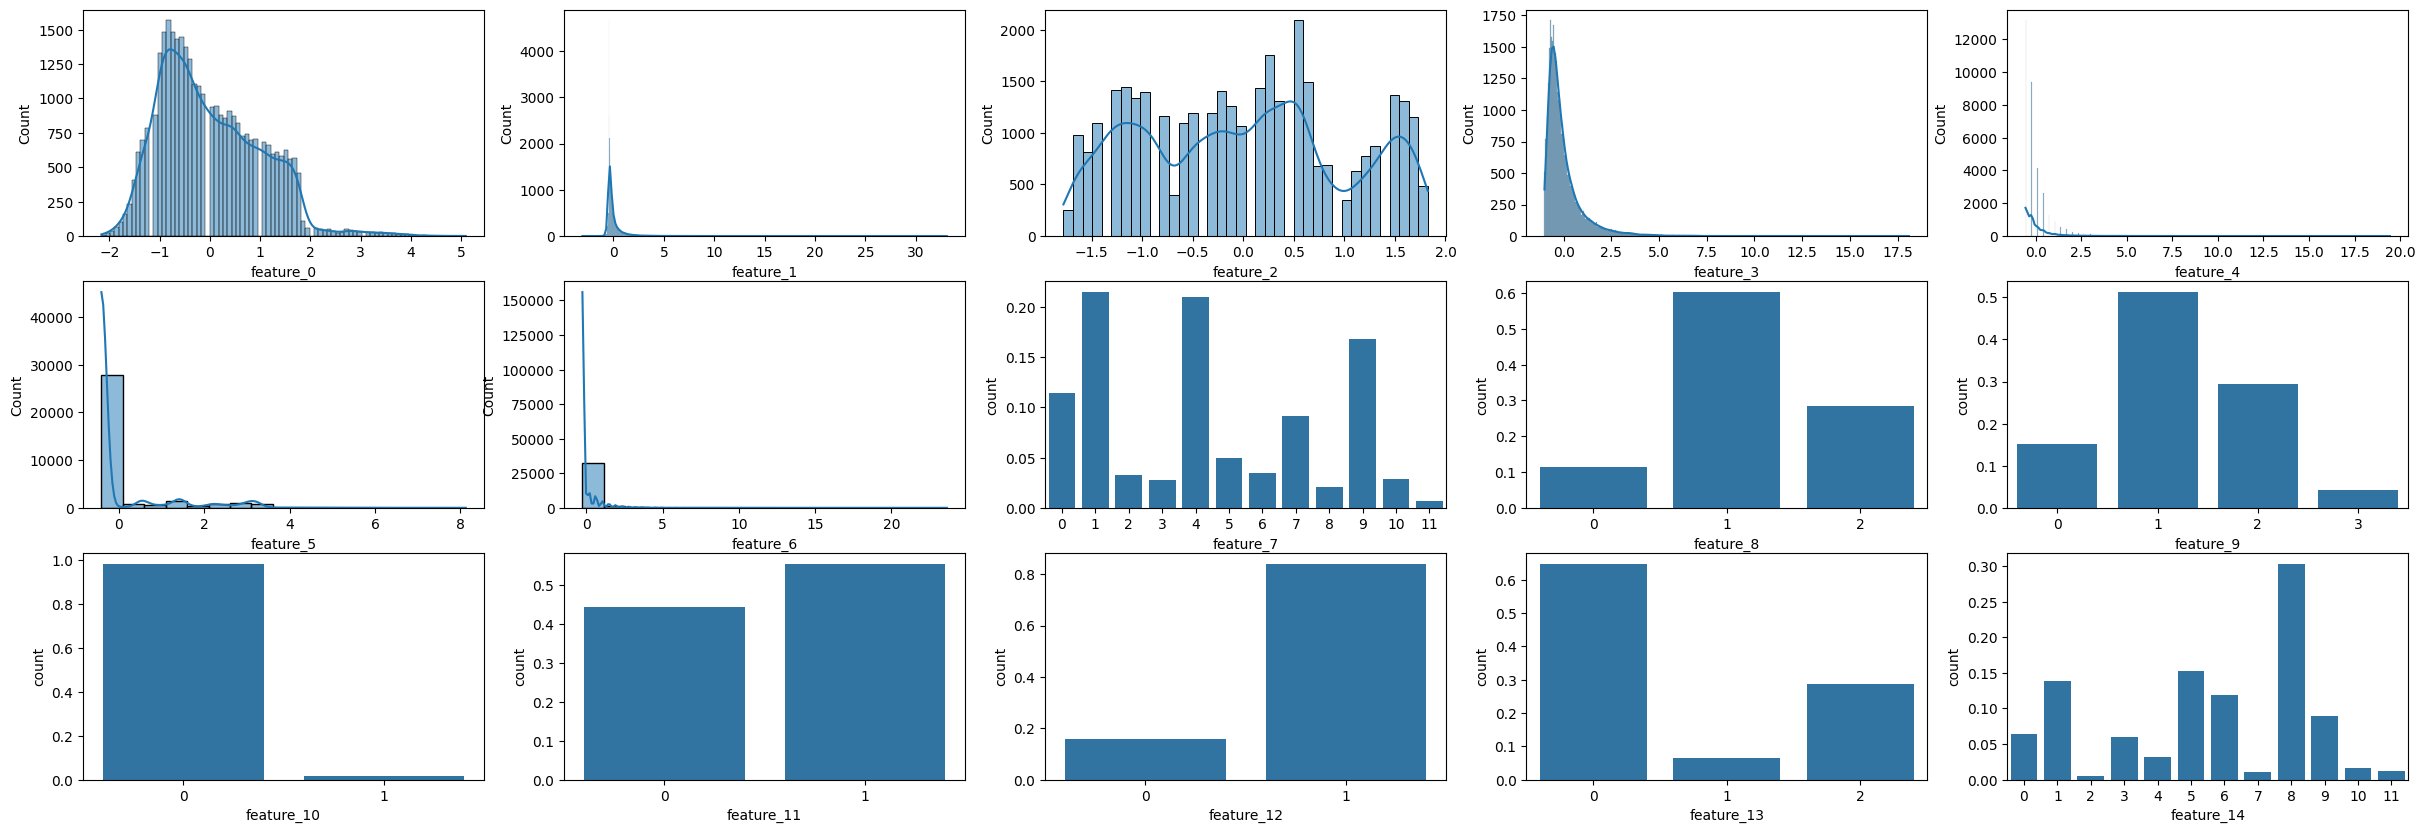

In [33]:
import seaborn as sns
from itertools import product

fig, axs = plt.subplots(3, 5, figsize=(30, 10))
idx = list(product(range(3), range(5)))

for i, c in zip(idx, real_db.columns):
    if int(c.split('_')[-1]) in range(7):
        sns.histplot(real_db[c], kde=True, ax=axs[i[0], i[1]])
    else:
        sns.barplot(real_db[c].value_counts(dropna=False)/real_db.shape[0], ax=axs[i[0], i[1]])

c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gbeno\Documents\m2_deng\machine_learning\venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, me

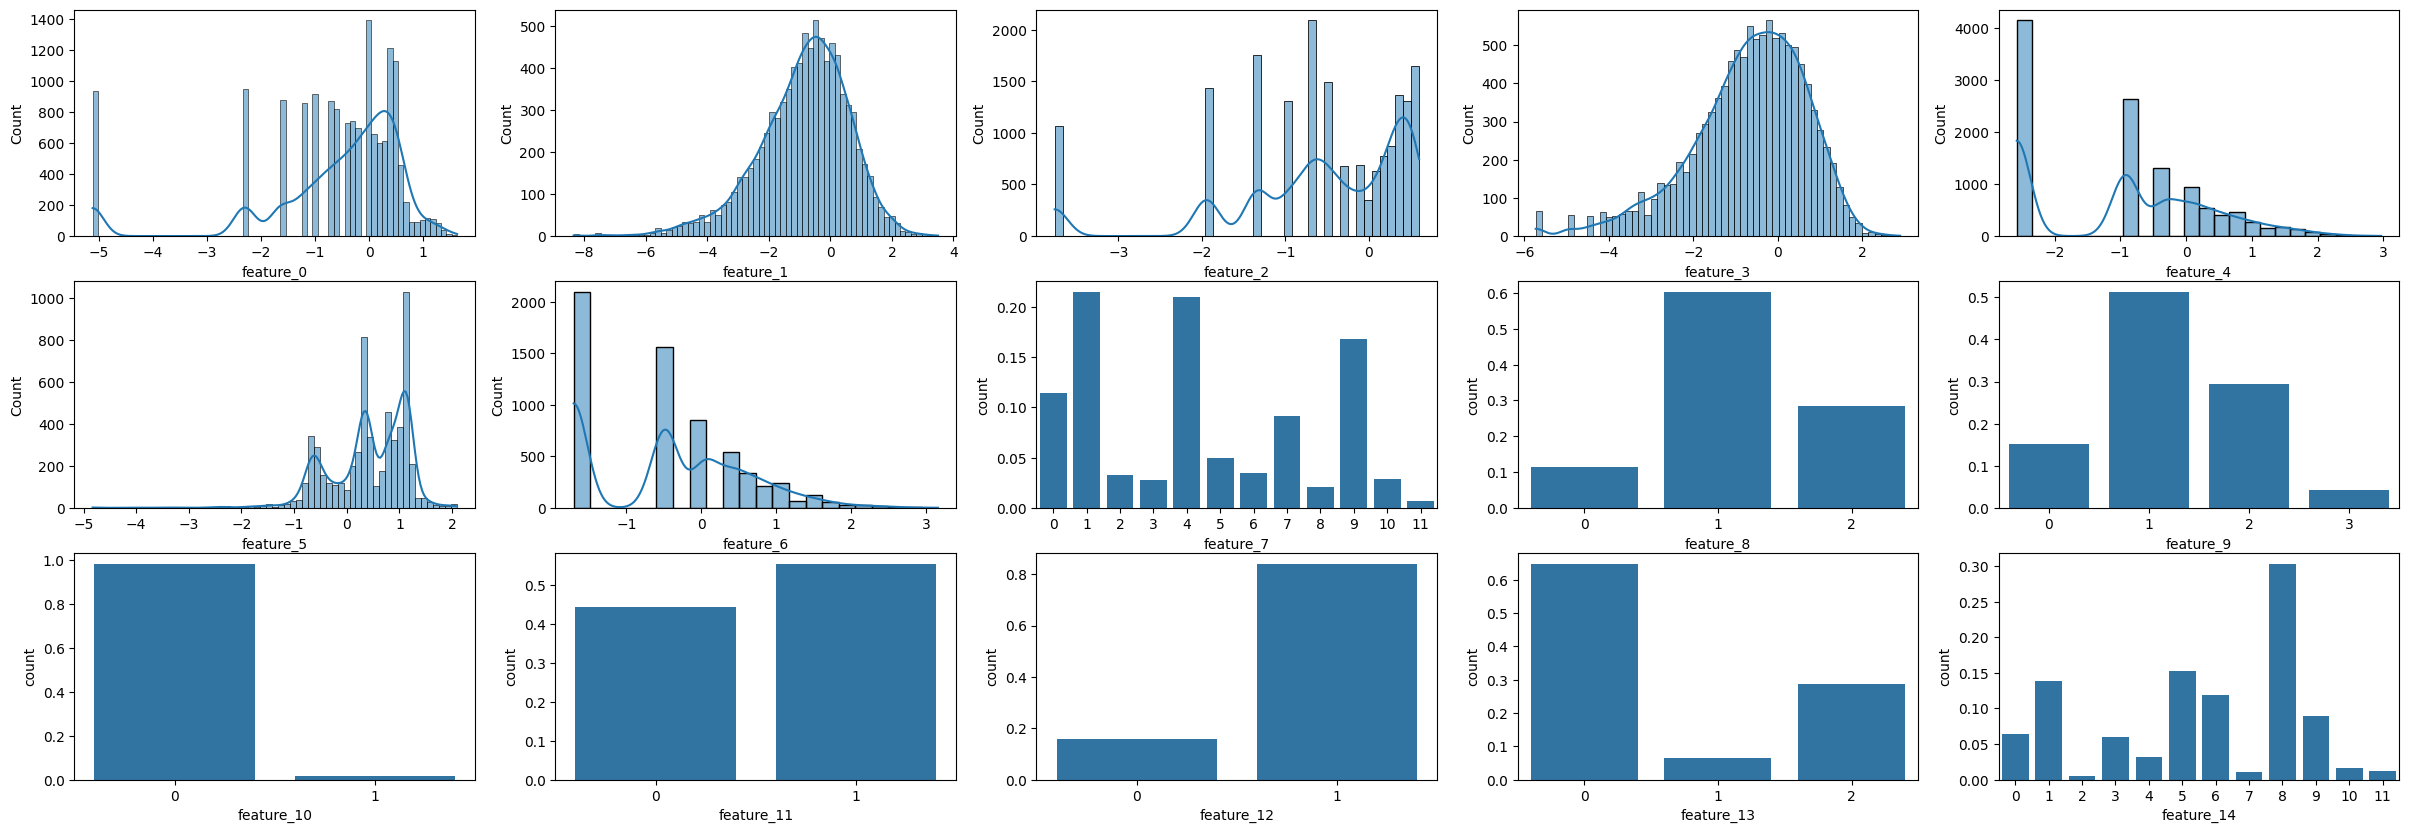

In [67]:
import seaborn as sns
from itertools import product

fig, axs = plt.subplots(3, 5, figsize=(30, 10))
idx = list(product(range(3), range(5)))

for i, c in zip(idx, real_db.columns):
    if int(c.split('_')[-1]) in range(7):
        real_db[c] = np.log(real_db[c])
        sns.histplot(real_db[c], kde=True, ax=axs[i[0], i[1]])
    else:
        sns.barplot(real_db[c].value_counts(dropna=False)/real_db.shape[0], ax=axs[i[0], i[1]])

*quand on loggue on perd de la data même si on arrive à retomber sur une distribution presque normale. essayer d'ajouter une quantité avant de logguer*

In [37]:
ks_2samp(X_test_scaled['remainder__GOOD_CREDIT'], real_db['feature_12'])

KstestResult(statistic=0.023670890285559493, pvalue=1.3121409776064734e-12, statistic_location=0.0, statistic_sign=1)

In [24]:
real_db['feature_12'].value_counts()

feature_12
0    28494
1     5414
Name: count, dtype: int64

In [27]:
real_db['feature_12'] = real_db['feature_12'].apply(lambda x: 1 if x == 0 else 0)
real_db['feature_12'].value_counts()

feature_12
1    28494
0     5414
Name: count, dtype: int64

In [35]:
from scipy.stats import ks_2samp
import numpy as np

In [70]:
df_real = real_db
df_simulated = X_train_scaled.copy()

# Créer une matrice de p-values
p_values_matrix = pd.DataFrame(index=df_real.columns, columns=df_simulated.columns)
d_matrix = pd.DataFrame(index=df_real.columns, columns=df_simulated.columns)

# Calculer les p-values pour chaque paire de variables
for real_col in df_real.columns:
    for sim_col in df_simulated.columns:
        # if np.issubdtype(df_real[real_col].dtype, np.number) and np.issubdtype(df_simulated[sim_col].dtype, np.number):
        _, p_value = ks_2samp(df_real[real_col].dropna(), df_simulated[sim_col].dropna())
        p_values_matrix.loc[real_col, sim_col] = round(p_value, 4)
        d_matrix.loc[real_col, sim_col] = round(_, 4)

In [71]:
p_values_matrix

,standard_scaler__INCOME,standard_scaler__CURR_ANN_AMT,standard_scaler__AGE_IN_YEARS,remainder__COUNTY_0,remainder__MARITAL_STATUS_0,remainder__CITY_0,remainder__HOME_MARKET_VALUE,remainder__DAYS_TENURE,remainder__HAS_CHILDREN,remainder__LENGTH_OF_RESIDENCE,remainder__HOME_OWNER,remainder__COLLEGE_DEGREE,remainder__GOOD_CREDIT,remainder__LATITUDE,remainder__LONGITUDE,YEARS_TENURE
feature_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feature_9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
d_matrix

,standard_scaler__INCOME,standard_scaler__CURR_ANN_AMT,standard_scaler__AGE_IN_YEARS,remainder__COUNTY_0,remainder__MARITAL_STATUS_0,remainder__CITY_0,remainder__HOME_MARKET_VALUE,remainder__DAYS_TENURE,remainder__HAS_CHILDREN,remainder__LENGTH_OF_RESIDENCE,remainder__HOME_OWNER,remainder__COLLEGE_DEGREE,remainder__GOOD_CREDIT,remainder__LATITUDE,remainder__LONGITUDE,YEARS_TENURE
feature_0,0.1803,0.2173,0.2525,0.982,0.9727,0.9968,0.8852,1.0,0.5938,0.8486,0.6526,0.5938,0.7871,1.0,1.0,0.6766
feature_1,0.3144,0.2571,0.3014,0.9717,0.9248,0.9865,0.8749,1.0,0.7082,0.8007,0.7082,0.7082,0.7392,1.0,1.0,0.7082
feature_2,0.241,0.2688,0.2361,1.0,1.0,1.0,0.9023,1.0,0.6221,0.8759,0.6799,0.6221,0.8144,1.0,1.0,0.7039
feature_3,0.26,0.2018,0.2603,0.9792,0.9218,0.994,0.8824,1.0,0.6608,0.7984,0.6608,0.6608,0.7362,1.0,1.0,0.6732
feature_4,0.4669,0.4199,0.3968,0.9744,0.9343,0.9892,0.8776,1.0,0.7139,0.8102,0.7139,0.7139,0.7487,1.0,1.0,0.7139
feature_5,0.5298,0.3007,0.3829,0.9804,0.7146,0.9952,0.8835,1.0,0.3034,0.7996,0.3945,0.4648,0.529,1.0,1.0,0.6744
feature_6,0.34,0.2995,0.3022,0.9731,0.9081,0.9879,0.8763,1.0,0.5929,0.7923,0.5929,0.5929,0.7225,1.0,1.0,0.6671
feature_7,0.82,0.7276,0.7342,0.3116,0.6097,0.5233,0.2148,1.0,0.6704,0.2263,0.6704,0.6704,0.6704,1.0,1.0,0.3499
feature_8,0.8216,0.7292,0.7357,0.6978,0.2371,0.9705,0.8331,1.0,0.4384,0.7213,0.2842,0.5998,0.2842,1.0,1.0,0.6409
feature_9,0.783,0.6905,0.6971,0.6464,0.1856,0.929,0.7916,1.0,0.3998,0.6798,0.3356,0.5611,0.3356,1.0,1.0,0.5994


In [ ]:
### Autres

### Autres

In [ ]:
# sauvegarder un data sample pour la demo  (ANNEXE)
import pickle

example = X_test.head(10)
example.insert(0, 'churn', y_test.head(10))
example = example.reset_index(drop=True)
with open('../ressources/models_fitted/data_sample.pkl', 'wb') as f:
    pickle.dump(example, f)

example = pickle.load(open('../ressources/models_fitted/data_sample.pkl', 'rb'))
example